In [1]:
import pandas as pd

from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark

In [2]:
df = pd.read_csv(
    "data\\OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

In [3]:
data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=chosen_ticker, no_plotting=True)


Shape dataset (6409, 11)
means:  Close           8.036797e+01
Volume          1.087093e+06
MarketCap       1.954685e+10
Weight          6.289315e-03
Return          4.417263e-04
LogReturn       1.723115e-04
WeightedRet     4.306955e-06
SMA20           8.029539e+01
EMA20           8.029467e+01
RSI14           5.211280e+01
ReturnVola20    2.049862e-02
dtype: float64
stds:  Close           7.186329e+01
Volume          9.459844e+05
MarketCap       1.747837e+10
Weight          3.087590e-03
Return          2.315582e-02
LogReturn       2.325378e-02
WeightedRet     1.423583e-04
SMA20           7.175884e+01
EMA20           7.168856e+01
RSI14           1.325365e+01
ReturnVola20    1.071267e-02
dtype: float64


In [4]:
data_values = data_values
window_step_length = 100
window_size = 100
num_test_points = 200

horizon = 2 #3 is good
target_idx = 0

n_features = data_values.shape[1]

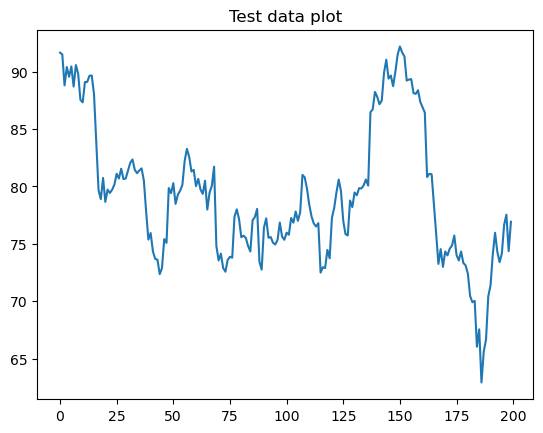

in sequences shape:  (62, 100, 11)
targets shape:  (62, 1)
train loader length:  2
val loader length:  1
Benchmark Celsius: 1.757118067457919
Normalized Benchmark: 0.02324805193248008


In [5]:
train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )

In [6]:
from train.train_functions import get_device, plot_training, test_model_output
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionGRUV2 import CrossAttentionGRUV2

import deeplay as dl
import torch

In [7]:
device = get_device()
print(device)

cuda:0


In [8]:
cross_attn_gru_v1 = CrossAttentionGRUV1(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)
cross_attn_gru_v2 = CrossAttentionGRUV2(in_dim=n_features, hidden_dim=144, num_hidden_layers=3, out_dim=1, dropout=0.1, num_heads=24)

In [9]:
epochs = 40

In [10]:
chosen_model = cross_attn_gru_v1
print(type(chosen_model))

<class 'single_asset_models.CrossAttentionGRUV1.CrossAttentionGRUV1'>


c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
INFO: 
  | Name          | Type                | Params | Mode 
--------------------------------------------------------------
0 | loss          | L1Loss              | 0      | train
1 | train_metrics | MetricCollection    | 0      | train
2 | val_metrics   | MetricCollection    | 0      | train
3 | test_metrics  | MetricCollection    | 0      | train
4 | model         | CrossAttentionGRUV1 | 445 K  | train
5 | optimizer     | Adam               

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=23` in the `DataLoader` to improve performance.
c:\Users\Gabriel\anaconda3\envs\py310torch-gpu\lib\site-packages\lightning\pytorch\loops\fit_loop.py:310: The number of training batches (2) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

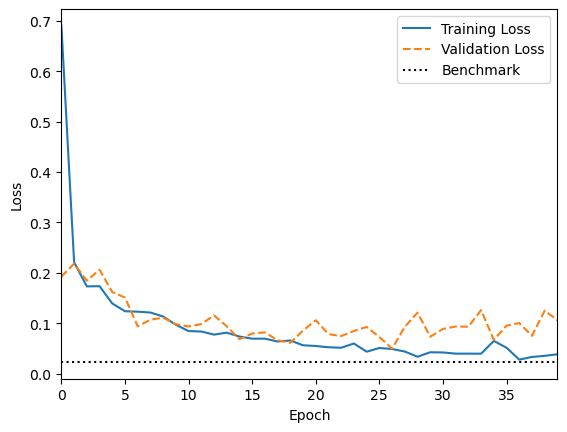

In [11]:
#trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)

chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
trainer.fit(chosen_model_reg, train_loader, val_loader)
train_losses = trainer.history.history["train_loss_epoch"]["value"]
val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
plot_training(epochs, train_losses, val_losses, benchmark)

In [12]:
test_model_output(model=chosen_model_reg, data_loader=val_loader, num_tests=10)

Last 10 timesteps (input) and true vs predicted temperature:
Sample 1: Last input temp = 0.03, True = -0.85, Pred = -0.88
Sample 2: Last input temp = -1.06, True = -0.87, Pred = -0.87
Sample 3: Last input temp = 0.41, True = 0.06, Pred = 0.10
Sample 4: Last input temp = -0.24, True = 0.29, Pred = 0.26
Sample 5: Last input temp = -1.14, True = -0.81, Pred = -0.79
Sample 6: Last input temp = -0.04, True = 0.21, Pred = 0.32
Sample 7: Last input temp = -0.83, True = -0.80, Pred = -0.80
Sample 8: Last input temp = -1.13, True = -0.84, Pred = -0.79
Sample 9: Last input temp = 0.10, True = 0.29, Pred = 0.48
Sample 10: Last input temp = -0.26, True = -0.44, Pred = -0.43


last window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])


c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_indicators, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch[(t)*horizon:(t+1)*horizon-1,:], dtype = torch.float32)


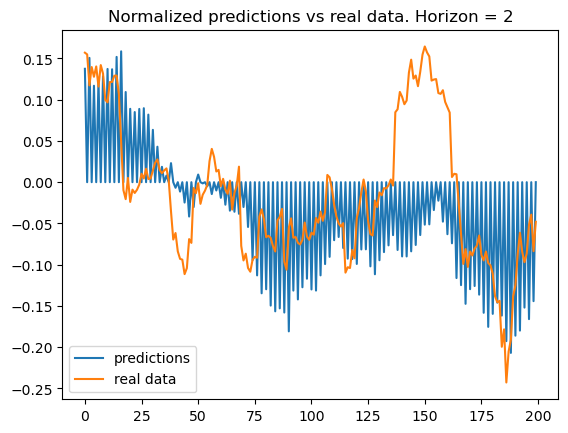

In [13]:
from model_inference.inference_functions import generate_predictions, plot_pred_vs_real

predictions_normalized = generate_predictions(chosen_model_reg, window_step_length, data_values, num_of_future_predictions=num_test_points, horizon=horizon)

plot_pred_vs_real(predictions_normalized, data_values, target_idx, horizon, minimal_plotting=True)

2
variance of returns for old data:  0.0010821420017512924
start window shape:  torch.Size([100, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(89.5000)
period from idx:  0  to idx  2
prediction at 2:  tensor(90.2461)
last price from test data:  89.5
real price 2 steps forward:  tensor(88.8000)
kelly weight:  {tensor(1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(91.5000)
period from idx:  2  to idx  4
prediction at 2:  tensor(91.2126)
last price from test data:  tensor(91.5000)
real price 2 steps forward:  tensor(89.5500)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(90.4000)
period from idx:  4  to idx  6
prediction at 2:  tensor(90.3127)
last price from test data:  tensor(90.4000)
real price 2 steps forward:  tensor(88.7000)
kelly weight:  {tensor(-0.8928)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(90.4500)
period from i

c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:172: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
c:\Users\Gabriel\Documents\GitHub\Project-AMLNN\model_inference\inference_functions.py:174: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start:idx_end-1,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(82.2000)
period from idx:  56  to idx  58
prediction at 2:  tensor(80.4279)
last price from test data:  tensor(82.2000)
real price 2 steps forward:  tensor(81.3000)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(82.5800)
period from idx:  58  to idx  60
prediction at 2:  tensor(81.9701)
last price from test data:  tensor(82.5800)
real price 2 steps forward:  tensor(80.0200)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(81.4400)
period from idx:  60  to idx  62
prediction at 2:  tensor(81.2147)
last price from test data:  tensor(81.4400)
real price 2 steps forward:  tensor(79.7300)
kelly weight:  {tensor(-1.)}
 
x_in shape:  torch.Size([1, 100, 11])
windows last price:  tensor(80.6600)
period from idx:  62  to idx  64
prediction at 2:  tensor(80.4430)
last price from test data:  tensor(80.6600)
real price 2 steps forward: 

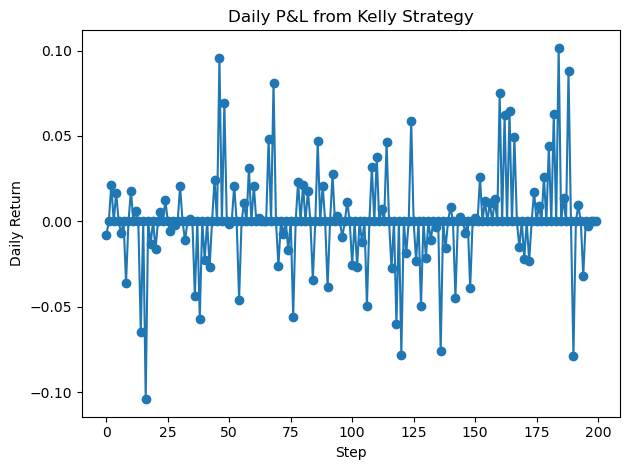

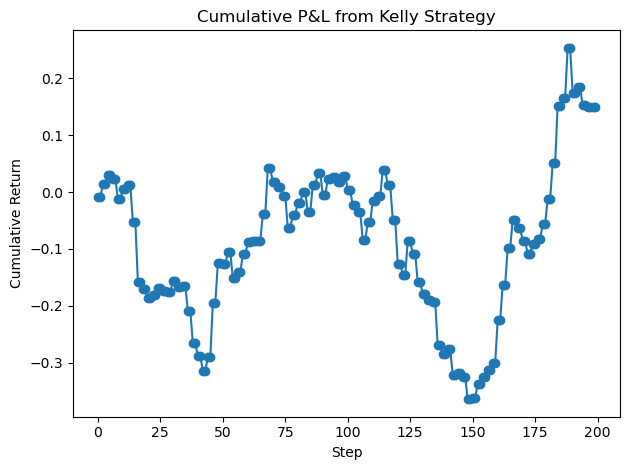

In [14]:
from model_inference.inference_functions import  generate_predictions_and_returns, plot_realized_returns
import matplotlib.pyplot as plt
import numpy as np

print(horizon)
preds_norm, weights, pnl = generate_predictions_and_returns(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  print_values_for_allocation=True)

plot_realized_returns(pnl, plot_only_cumulative=False)

In [15]:
print(weights)
print()
print(pnl)

'''Model version_61 had 0.02 in mae'''

[ 1.          0.         -1.          0.         -0.89282638  0.
  1.          0.          1.          0.          1.          0.
  1.          0.          1.          0.          1.          0.
  1.          0.          1.          0.          1.          0.
  1.          0.          1.          0.          1.          0.
  1.          0.          1.          0.          1.          0.
  1.          0.          1.          0.          1.          0.
  1.          0.          1.          0.          1.          0.
  1.          0.          1.          0.          1.          0.
 -1.          0.         -1.          0.         -1.          0.
 -1.          0.         -1.          0.          0.09213776  0.
  1.          0.         -1.          0.          1.          0.
  1.          0.         -1.          0.         -1.          0.
 -1.          0.         -1.          0.         -1.          0.
 -1.          0.         -1.          0.         -1.          0.
 -1.          0.         

'Model version_61 had 0.02 in mae'